# Optical Flow for IFU Spectral Cubes
## Kinematic Source Detection using Starlet Transforms & PyTorch

This notebook implements a differentiable optical flow pipeline specifically designed for Integral Field Unit (IFU) data. 
By treating the spectral axis as a pseudo-time axis, we track the spatial movement of sources caused by Doppler shifts.

### Key Features:
1. **Starlet Transform (B3-Spline):** Using `F.conv2d` for multi-scale source masking.
2. **Brightness-Agnostic Flow:** Incorporating a learnable gain field ($\alpha$) to handle emission line evolution.
3. **PyTorch Backend:** Directly handling gradients for flow optimization.

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Configuration
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Using device: {device}")

Using device: mps


### 1. Starlet Transform Implementation
The Starlet (Isotropic Undecimated Wavelet) transform is ideal for astronomical source detection because it is isotropic and preserves the center of light.

In [2]:
def starlet_kernel():
    # B3-spline kernel: [1/16, 1/4, 3/8, 1/4, 1/16]
    k = torch.tensor([0.0625, 0.25, 0.375, 0.25, 0.0625])
    kernel_2d = torch.outer(k, k).unsqueeze(0).unsqueeze(0)
    return kernel_2d

def get_starlet_mask(img, level=3, sigma_thresh=3.0):
    """
    Extracts binary masks for sources using Wavelet detail layers.
    img: (1, 1, H, W)
    """
    kernel = starlet_kernel().to(img.device)
    current_approx = img
    masks = []
    
    for j in range(1, level + 1):
        # Atrous (holey) algorithm for higher levels
        if j > 1:
            step = 2**(j-1)
            # Size of kernel increases as 1 + (k-1)*step
            k_size = 5 + (5-1)*(step-1)
            new_k = torch.zeros((1, 1, k_size, k_size)).to(img.device)
            k_base = starlet_kernel().to(img.device)
            for r in range(5):
                for c in range(5):
                    new_k[0, 0, r*step, c*step] = k_base[0, 0, r, c]
            active_kernel = new_k
        else:
            active_kernel = kernel

        padding = (active_kernel.shape[-1] - 1) // 2
        next_approx = F.conv2d(current_approx, active_kernel, padding=padding)
        
        # Detail layer w = c_j - c_{j+1}
        detail = current_approx - next_approx
        
        # Thresholding for mask
        std = torch.std(detail)
        mask = (torch.abs(detail) > sigma_thresh * std).float()
        masks.append(mask)
        current_approx = next_approx
        
    # Combine masks across scales (Logical OR)
    return torch.max(torch.stack(masks), dim=0)[0]

### 2. Optical Flow with Brightness Compensation
We define a loss function that optimizes flow vectors $(u, v)$ and a local gain field $\alpha$ simultaneously.

In [3]:
def compute_optical_flow_step(img_curr, img_next, mask, lr=0.02, iterations=200):
    """
    Optimizes flow between two spectral slices.
    """
    B, C, H, W = img_curr.shape

    # Initialize Flow (u, v) and Alpha (gain)
    # flow units are in normalized grid coordinates
    flow = torch.zeros((1, 2, H, W), requires_grad=True, device=device)
    alpha = torch.ones((1, 1, H, W), requires_grad=True, device=device)

    optimizer = torch.optim.Adam([flow, alpha], lr=lr)

    # Pre-compute identity grid
    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1, 1, H, device=device),
        torch.linspace(-1, 1, W, device=device),
        indexing='ij'
    )
    base_grid = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(0)  # (1, H, W, 2)

    for i in range(iterations):
        optimizer.zero_grad()

        # Warp next image back to current coordinate system
        v_grid = base_grid + flow.permute(0, 2, 3, 1)
        warped_next = F.grid_sample(img_next, v_grid, align_corners=True, mode='bilinear')

        # Photometric error with learnable intensity scaling alpha
        # Loss = Mask * [I_next(x+v) - alpha * I_curr(x)]^2
        photo_loss = torch.sum(mask * (warped_next - alpha * img_curr)**2)

        # Total Variation Smoothness
        grad_u_y = flow[:, 0, 1:, :] - flow[:, 0, :-1, :]
        grad_u_x = flow[:, 0, :, 1:] - flow[:, 0, :, :-1]
        grad_v_y = flow[:, 1, 1:, :] - flow[:, 1, :-1, :]
        grad_v_x = flow[:, 1, :, 1:] - flow[:, 1, :, :-1]
        reg_loss = 0.05 * (grad_u_y.abs().mean() + grad_u_x.abs().mean() +
                           grad_v_y.abs().mean() + grad_v_x.abs().mean())

        total_loss = photo_loss + reg_loss
        total_loss.backward()
        optimizer.step()

        if i % 50 == 0:
            print(f"Iter {i}: Loss {total_loss.item():.6f}")

    return flow.detach(), alpha.detach()

/Users/arnablahiry/miniforge3/envs/cosmostat/lib/python3.11/site-packages/torch/autograd/graph.py:824: UserWarning: The operator 'aten::grid_sampler_2d_backward' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:14.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Iter 0: Loss 0.502052
Iter 50: Loss 0.001356
Iter 100: Loss 0.000703
Iter 150: Loss 0.000675


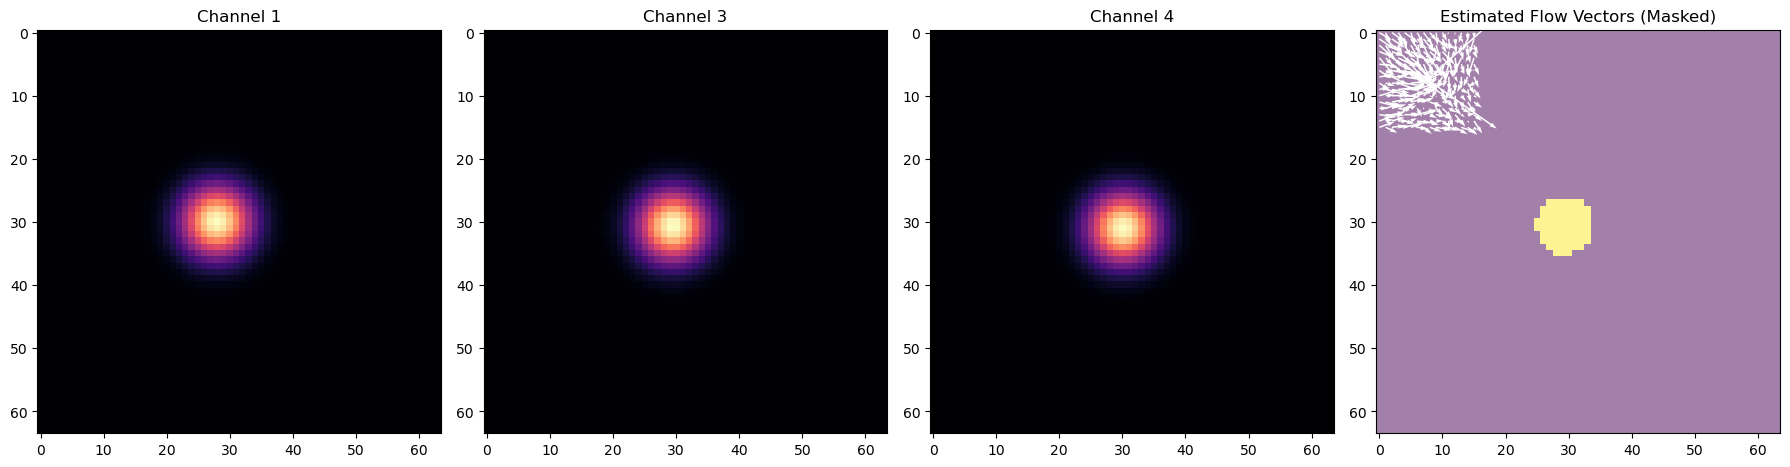

In [4]:
# 1. Create a small spectral cube with a Gaussian source that drifts and fades
H, W = 64, 64
n_channels = 8
cube = torch.zeros((n_channels, 1, H, W), device=device)

y, x = np.ogrid[:H, :W]
for channel in range(n_channels):
    x_center = 28 + channel * 0.7
    y_center = 30 + channel * 0.35
    amplitude = 1.0 - 0.08 * channel
    sigma = 4.0
    source = amplitude * np.exp(-((x - x_center)**2 + (y - y_center)**2) / (2 * sigma**2))
    cube[channel, 0] = torch.from_numpy(source).float()

# 2. Compare adjacent spectral slices
img1 = cube[2:3]
img2 = cube[3:4]

# 3. Get Wavelet Mask
mask = get_starlet_mask(img1, level=2)

# 4. Compute Flow
flow, alpha = compute_optical_flow_step(img1, img2, mask)

# 5. Plot Results
fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(cube[0, 0].cpu(), cmap='magma'); ax[0].set_title("Channel 1")
ax[1].imshow(img1[0, 0].cpu(), cmap='magma'); ax[1].set_title("Channel 3")
ax[2].imshow(img2[0, 0].cpu(), cmap='magma'); ax[2].set_title("Channel 4")

# Quiver plot of flow vectors
fy, fx = flow[0, 1].cpu(), flow[0, 0].cpu()
ax[3].quiver(fx[::4, ::4], -fy[::4, ::4], color='white')
ax[3].imshow(mask[0, 0].cpu(), alpha=0.5)
ax[3].set_title("Estimated Flow Vectors (Masked)")
plt.tight_layout()
plt.show()